<a href="https://colab.research.google.com/github/koushal-code/DecodeLabs-Project/blob/main/optical_charecter_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optical Charecter Recognition

In [ ]:
!apt-get install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


In [ ]:
import cv2
import pytesseract
from pytesseract import Output

[VALIDATED] Text: 'On' | Confidence: 93%
[VALIDATED] Text: '26' | Confidence: 96%
[VALIDATED] Text: 'April' | Confidence: 96%
[VALIDATED] Text: '1986,' | Confidence: 90%
[VALIDATED] Text: 'reactor' | Confidence: 94%
[VALIDATED] Text: '4' | Confidence: 96%
[VALIDATED] Text: 'of' | Confidence: 96%
[VALIDATED] Text: 'the' | Confidence: 96%
[VALIDATED] Text: 'Chernobyl' | Confidence: 85%
[VALIDATED] Text: 'Nuclear' | Confidence: 96%
[VALIDATED] Text: 'Power' | Confidence: 96%
[VALIDATED] Text: 'Plant,' | Confidence: 96%
[VALIDATED] Text: 'near' | Confidence: 90%
[VALIDATED] Text: 'Ukraine,' | Confidence: 96%
[VALIDATED] Text: 'exploded.' | Confidence: 94%
[VALIDATED] Text: 'With' | Confidence: 96%
[VALIDATED] Text: 'dozens' | Confidence: 93%
[VALIDATED] Text: 'of' | Confidence: 96%
[VALIDATED] Text: 'direct' | Confidence: 96%
[VALIDATED] Text: 'casualties' | Confidence: 96%
[VALIDATED] Text: 'and' | Confidence: 96%
[VALIDATED] Text: 'thousands' | Confidence: 94%
[VALIDATED] Text: 'of' | Co

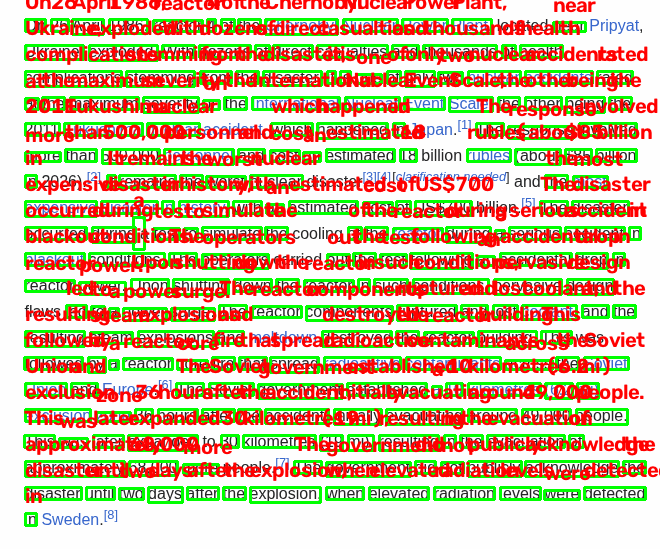

In [15]:
from google.colab.patches import cv2_imshow

image_path = "/content/text_image1.png"
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found. Please upload an image to your environment.")
else:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    processed_img = cv2.adaptiveThreshold(
        gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    ocr_data = pytesseract.image_to_data(processed_img, output_type=Output.DICT)

    output_image = image.copy()
    n_boxes = len(ocr_data['text'])
    detections_found = 0

    for i in range(n_boxes):
        confidence = int(ocr_data['conf'][i])
        text = ocr_data['text'][i].strip()

        if confidence >= 80 and len(text) > 0:
            detections_found += 1
            x, y = ocr_data['left'][i], ocr_data['top'][i]
            w, h = ocr_data['width'][i], ocr_data['height'][i]

            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(output_image, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

            print(f"[VALIDATED] Text: '{text}' | Confidence: {confidence}%")

    if detections_found == 0:
        print("No text met 80% accuracy.")
    else:
        print("\n--- Image Output ---")
        cv2_imshow(output_image)